download city's graph

In [3]:
import osmnx as ox

place = "Paris, France"
G = ox.graph_from_place(place, network_type="drive", simplify=True)
G = ox.project_graph(G)

download gnn model from hugging face

In [ ]:
from huggingface_hub import hf_hub_download
import torch

model_path = hf_hub_download(
    repo_id="nochka/street-pattern-classifier",
    filename="best_model.pth",
    local_dir="./models"
)

split graph to subgraphs (grid or community detection)

In [5]:
from splits import split_graph
# subgraphs = split_graph(G, resolution=50)
subgraphs = split_graph(G, grid_step=2000)

Assigning edges to cells: 100%|██████████| 18174/18174 [00:03<00:00, 4625.33it/s]


make dataset from subgraphs

In [8]:
from block_dataset import BlockDataset
dataset = BlockDataset(subgraphs)

Computing features for all subgraphs...


Processing subgraphs...: 100%|██████████| 32/32 [12:21<00:00, 23.16s/it]

Normalization...
Number of nodes: 6848
Number of features: 8
Подготовлено 32 блоков с корректными признаками


classification

In [9]:
from classification import classify_blocks
predictions_blocks, probabilities_blocks = classify_blocks(
    dataset,
    model_path=model_path,
    device='cuda'
)

Модель загружена


Processing batches: 100%|██████████| 1/1 [00:02<00:00,  2.03s/it]


visualization

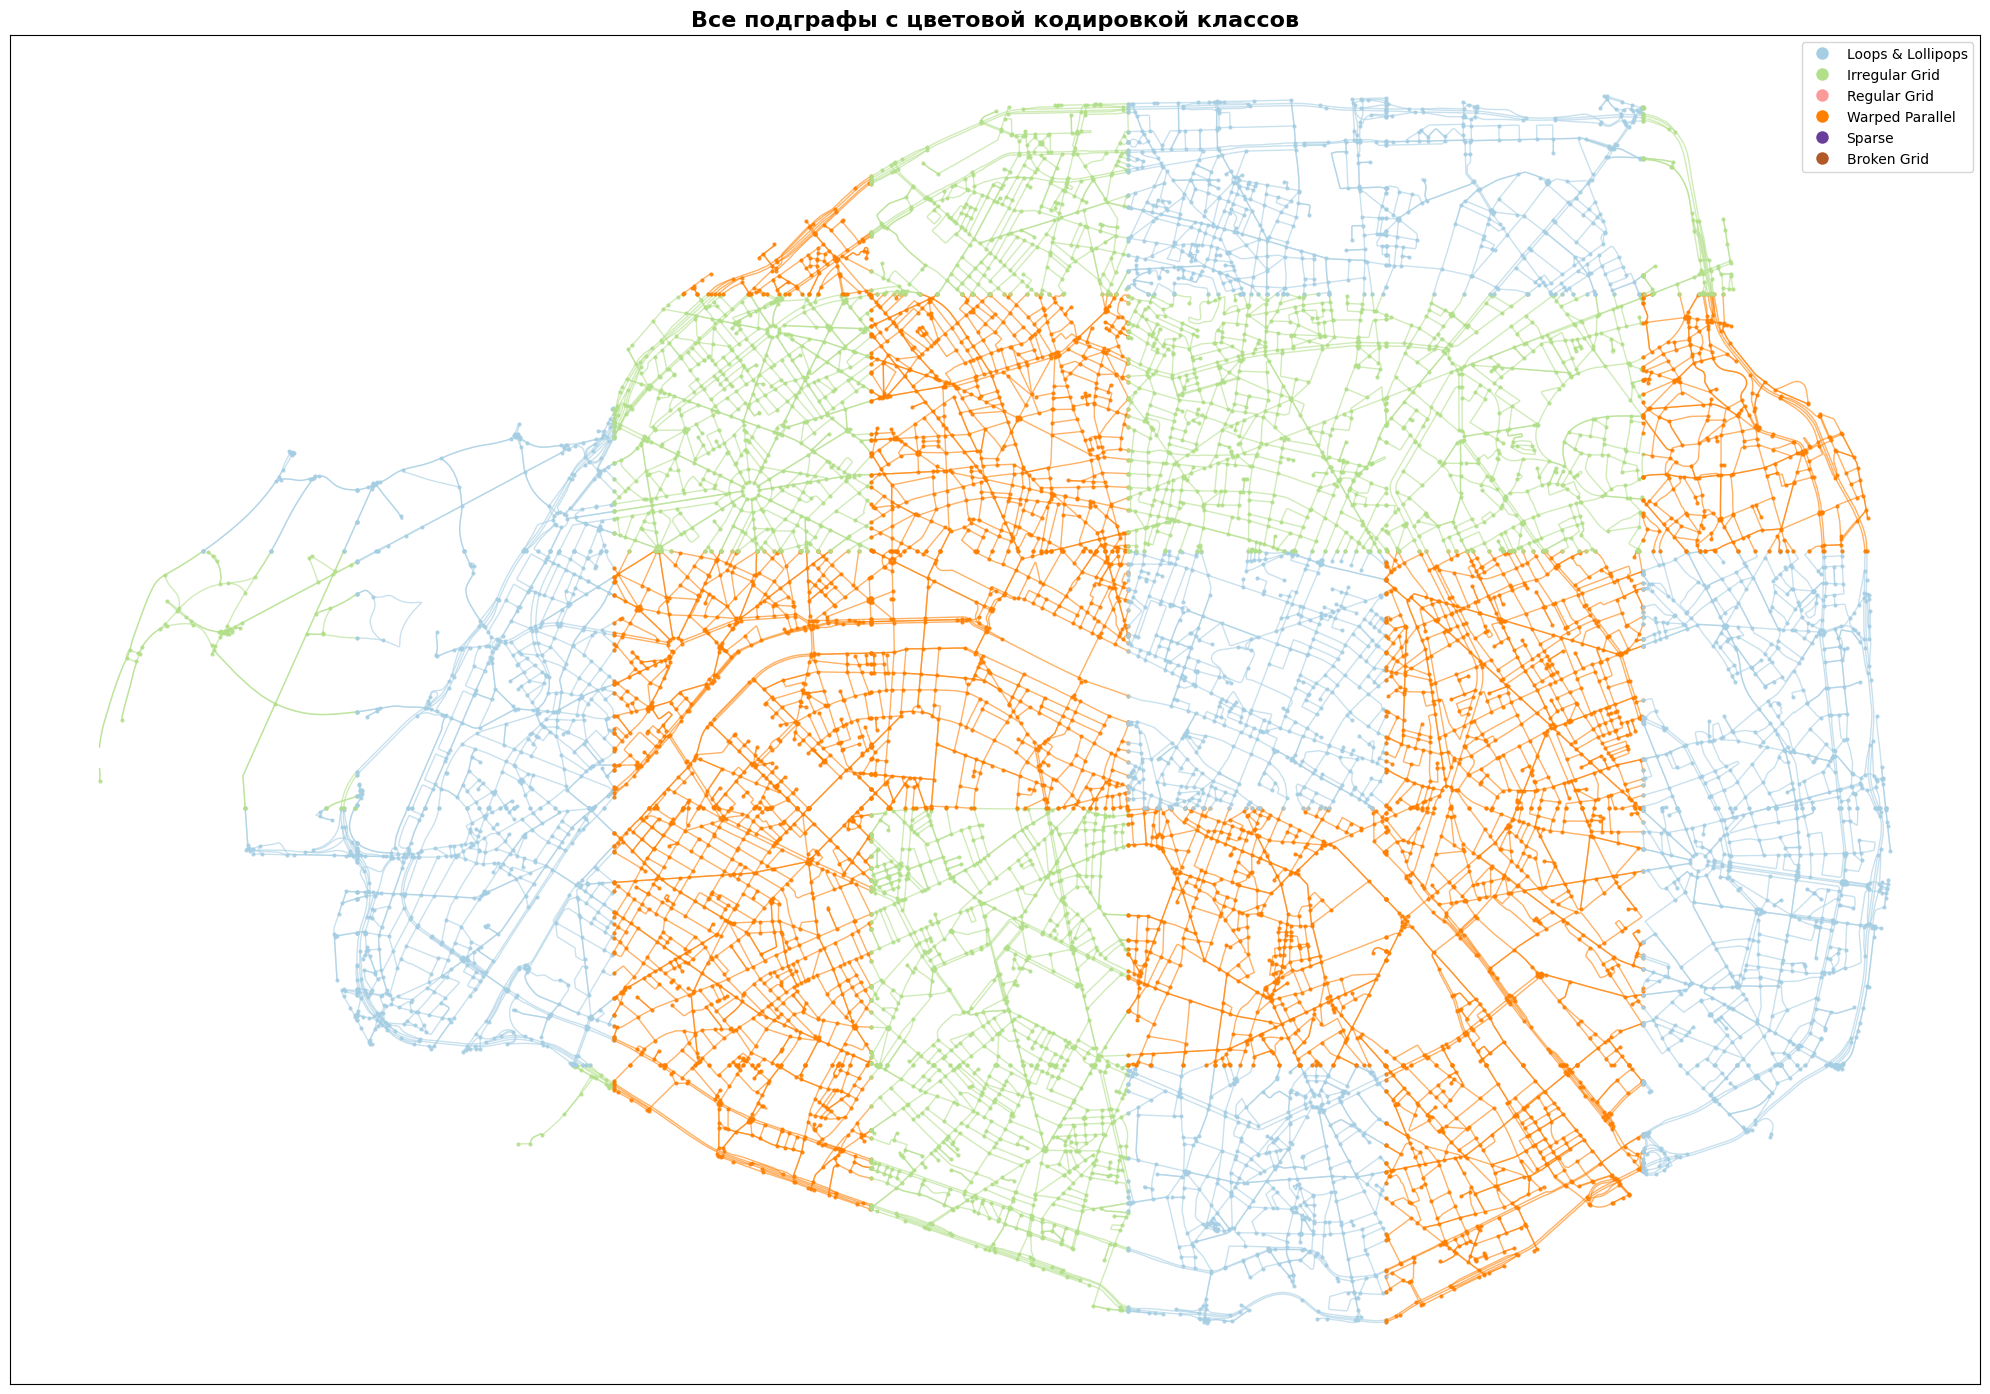

In [13]:
from plots import plot_all_subgraphs
from model import class_names

plot_all_subgraphs(subgraphs, predictions_blocks, class_names, (20,20))

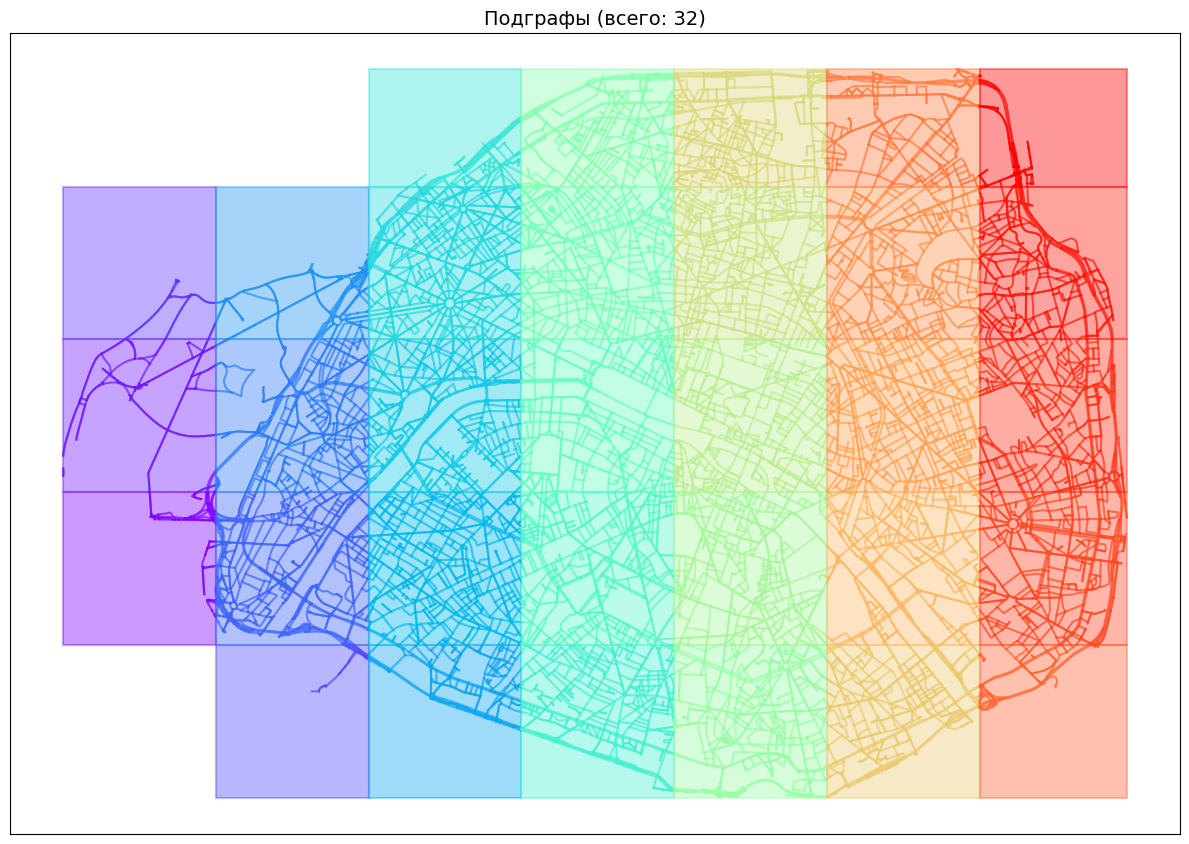

In [14]:
from plots import plot_subgraphs_polygons
plot_subgraphs_polygons(subgraphs)

/content/plots.py:264: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=3.0, w_pad=3.0)


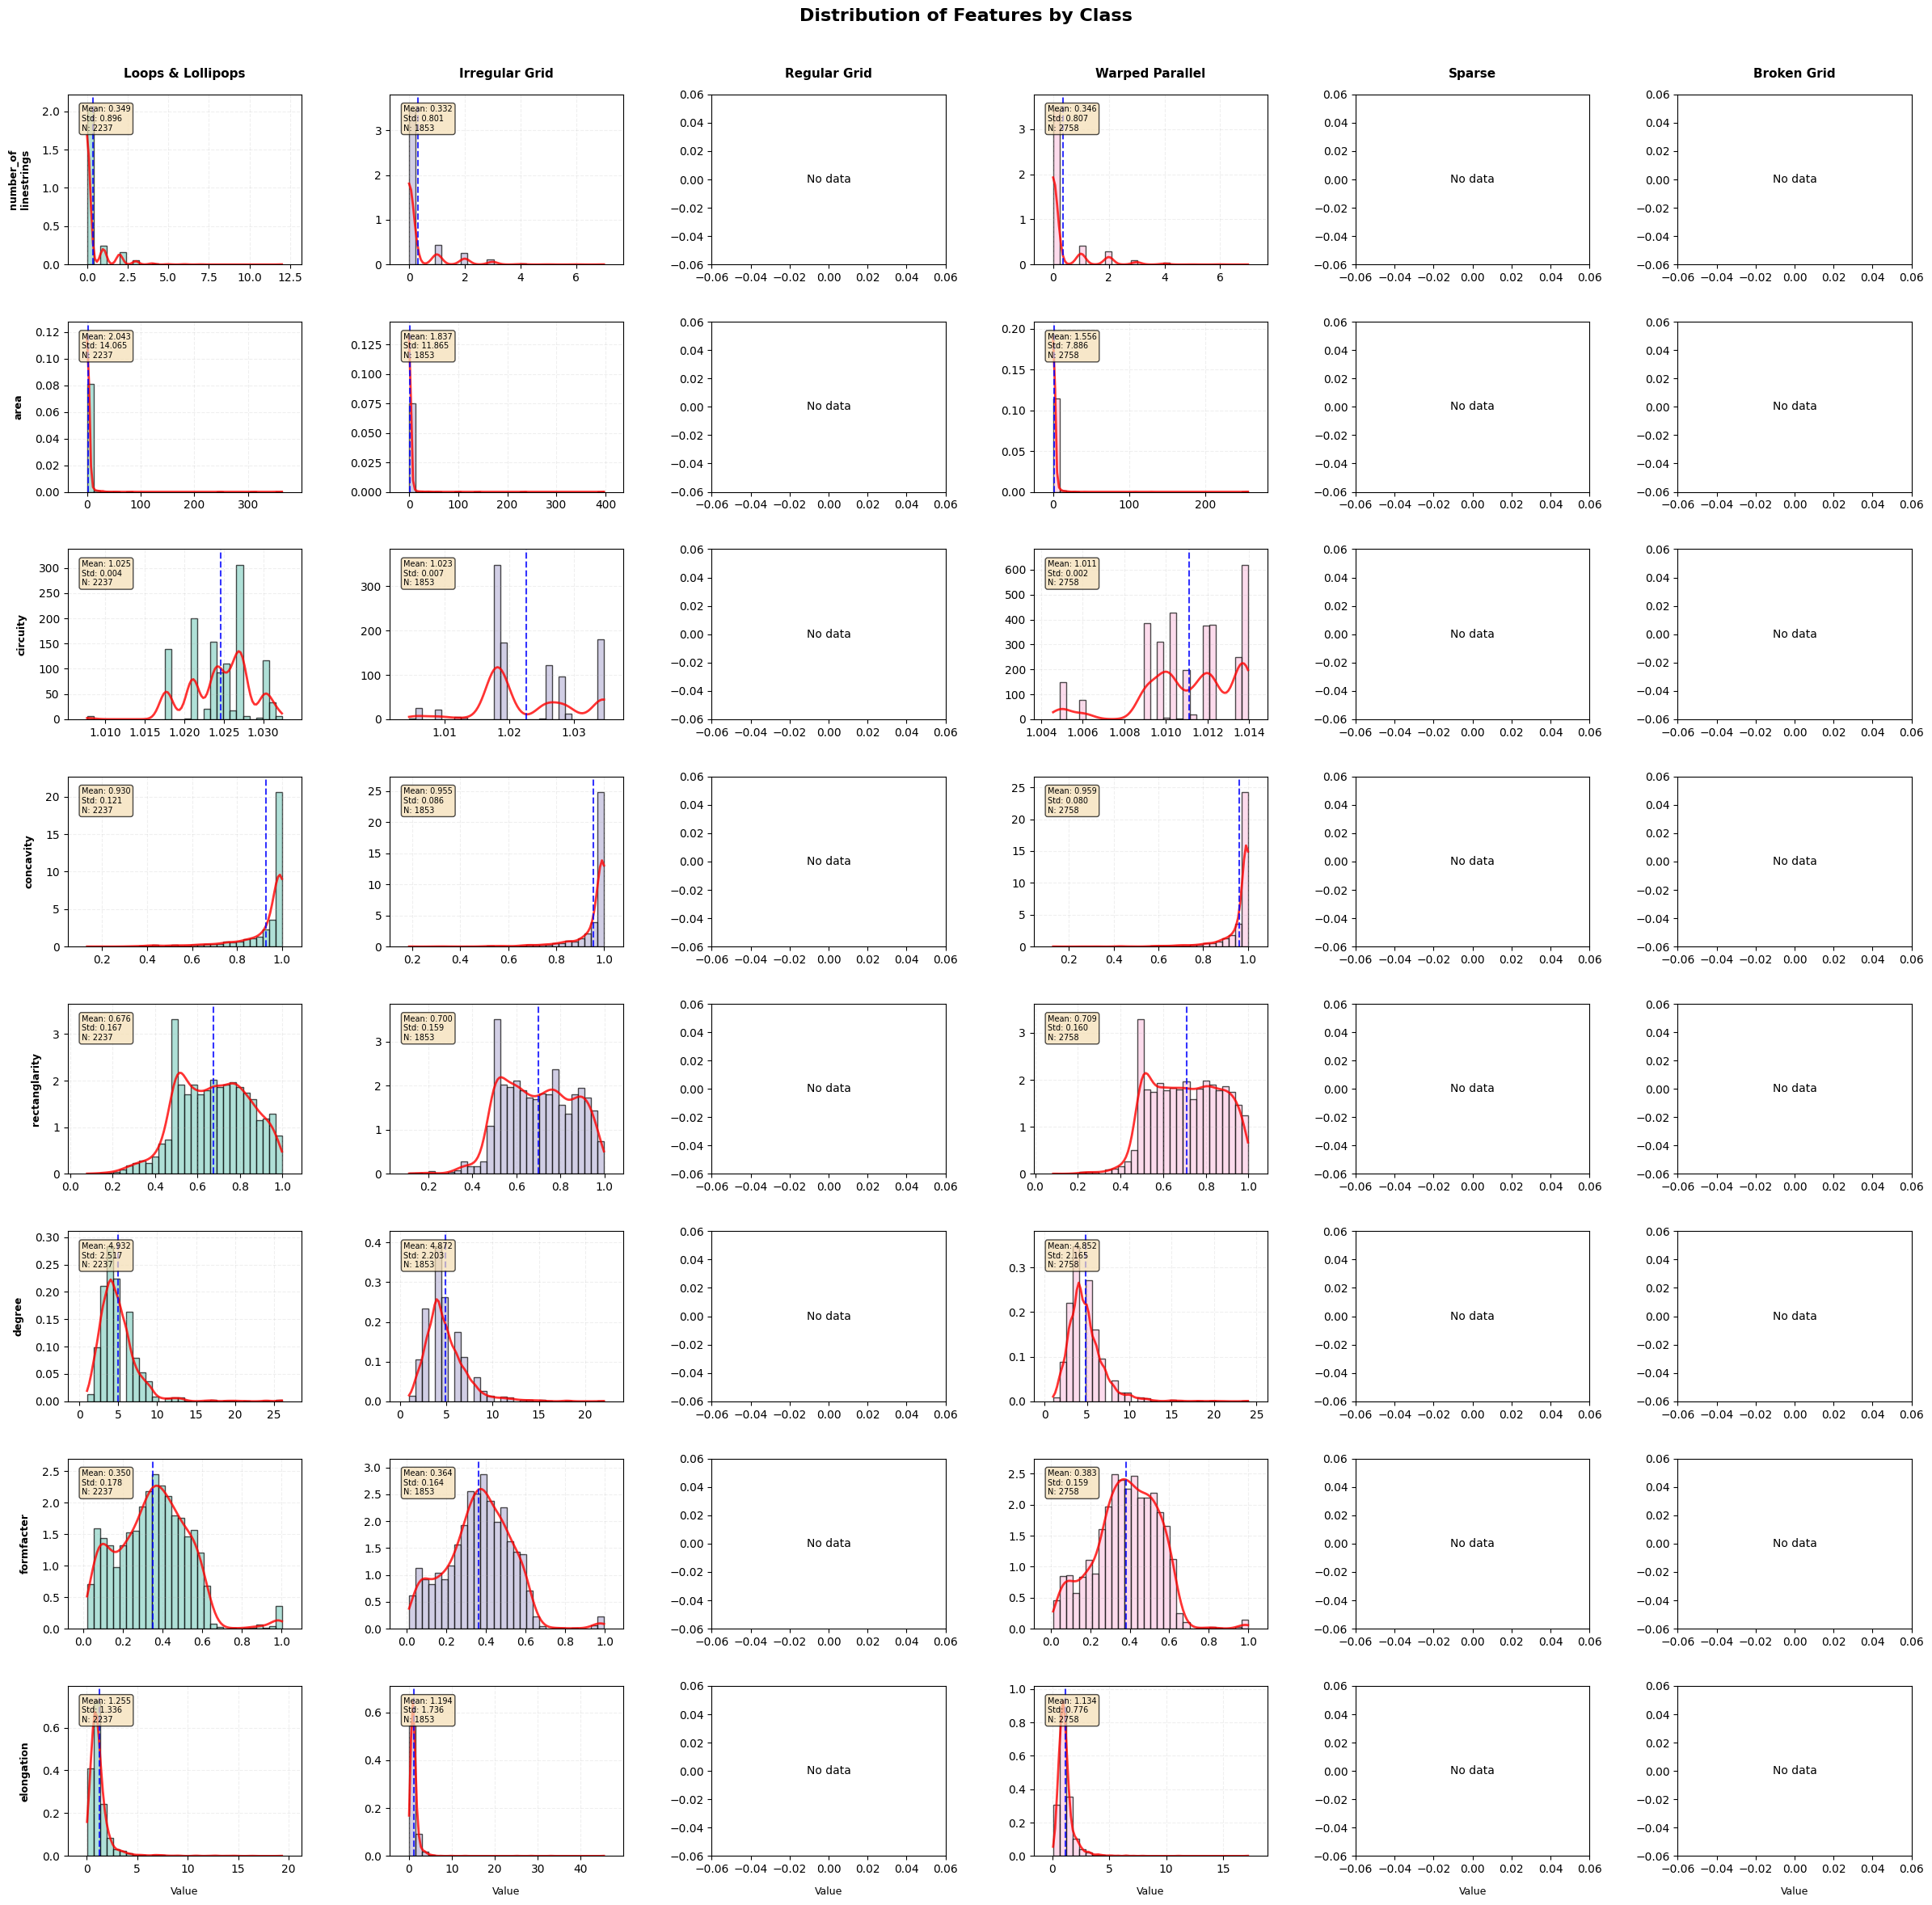

In [16]:
from plots import plot_features_by_class
from model import class_names
features = plot_features_by_class(dataset, predictions_blocks, class_names)